In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import pandas as pd

data_folder_path = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

# Run ProSeg

In [ ]:
threads = 16

transcript_file = (data_folder_path / "transcripts.csv.gz").resolve()

f"proseg {transcript_file} --xenium --nthreads {threads} --excluded-genes='^(BLANK|NegControl)'"

# Run MapMyCells

In [2]:
import anndata as ad

In [3]:
adata = ad.io.read_csv("expected-counts.csv.gz")
adata.write_h5ad("proseg.h5ad")

del adata

Download anndata and run mapmycells

# Analysis

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sys

import matplotlib

sys.path.append("../..")

from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [22]:
from pathlib import Path

data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

There are 2 cell-IDs, the original and the new ProSeg. Given that the largest dataframe (transcripts) uses the latter we are genereally gonna use these.

In [5]:
transcripts = pd.read_csv(
    "transcript-metadata.csv.gz",
    usecols=["observed_x", "observed_y", "observed_z", "assignment", "gene"],
    dtype={"gene": "category"},
).rename(columns={"assignment": "cell_id", "gene": "Gene"})
transcripts.columns = transcripts.columns.str.lstrip("observed_")

In [6]:
cells = pd.read_csv("cell-metadata.csv.gz", index_col=0)

In [7]:
mapmycells_df_3d = pd.read_csv("proseg_mapmycells.csv", comment="#", index_col=0)
# mapmycells_df_3d.index = mapmycells_df_3d.index.map(cell_id_map)

annotation = (
    mapmycells_df_3d[["class_name", "cluster_name"]]
    .rename(columns={"class_name": "celltype", "cluster_name": "cluster"})
    .astype("category")
)

coordinate_df_3d = transcripts.merge(
    annotation, how="left", left_on="cell_id", right_index=True
)

del annotation

In [8]:
xlim = (2800, 4800)
ylim = (550, 1400)

In [9]:
area_of_interest = cells["centroid_x"].between(*xlim) & cells["centroid_y"].between(
    *ylim
)

area_vlmc = area_of_interest & (cells["centroid_y"] < 1220)

vlmc = mapmycells_df_3d["subclass_name"].str.contains("VLMC")

plain_vlmc_mask = area_vlmc & vlmc & cells["centroid_x"].between(3200, 3850)

overlap_vlmc_mask = area_vlmc & vlmc & ~plain_vlmc_mask
overlap_vlmc_mask &= ~((cells["centroid_x"] > 4250) & (cells["centroid_y"] > 900))

In [10]:
clean_vlmcs = cells[plain_vlmc_mask]
fold_vlmcs = cells[overlap_vlmc_mask]
total_vlmcs = cells[plain_vlmc_mask | overlap_vlmc_mask]

In [11]:
coordinate_df_3d_clean_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell_id"].isin(clean_vlmcs.index)
]
coordinate_df_3d_fold_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell_id"].isin(fold_vlmcs.index)
]
coordinate_df_3d_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell_id"].isin(total_vlmcs.index)
]

In [12]:
ax_kwargs = dict(
    facecolor="k", aspect="equal", xlabel=None, ylabel=None, xticks=[], yticks=[]
)
ax_lims = dict(xlim=xlim, ylim=ylim)

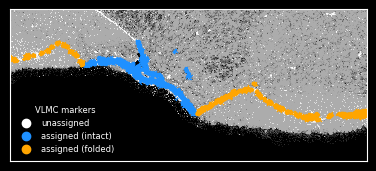

In [13]:
endothelial_markers = ("Aldh1a2", "Col1a1", "Fmod", "Slc13a4")

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(13.5 * CM, 5 * CM))

    scatter_kwargs = dict(x="x", y="y", rasterized=True, ax=ax, lw=0)

    sns.scatterplot(
        data=coordinate_df_3d[coordinate_df_3d["y"].between(*ylim)],
        s=0.5,
        alpha=0.1,
        c="dimgrey",
        **scatter_kwargs,
    )
    sns.scatterplot(
        data=coordinate_df_3d[
            lambda df: df["y"].between(*ylim) & df["Gene"].isin(endothelial_markers)
        ],
        s=0.5,
        alpha=0.5,
        c="white",
        **scatter_kwargs,
    )
    sns.scatterplot(
        data=coordinate_df_3d_clean_vlmcs, s=1, c="dodgerblue", **scatter_kwargs
    )
    sns.scatterplot(data=coordinate_df_3d_fold_vlmcs, s=1, c="orange", **scatter_kwargs)

    plt.legend(
        handles=[
            plt.scatter([], [], c=c, label=l)
            for c, l in zip(
                ["white", "dodgerblue", "orange"],
                ["unassigned", "assigned (intact)", "assigned (folded)"],
            )
        ],
        title="VLMC markers",
        frameon=False,
        loc="lower left",
    )

    ax.set(**ax_kwargs, **ax_lims)

    fig.savefig("proseg_vlmcs.svg", **save_kwargs)

In [14]:
coordinate_df_3d["celltypes_short"] = (
    coordinate_df_3d["celltype"].str.split(" ").str[-1]
)
coordinate_df_3d.loc[
    coordinate_df_3d["cluster"].str.contains("VLMC", na=False), "celltypes_short"
] = "VLMC"
coordinate_df_3d["celltypes_short"] = coordinate_df_3d["celltypes_short"].astype(
    "category"
)

In [15]:
from matplotlib.cm import Set3

celltypes = coordinate_df_3d["celltypes_short"].cat.categories

ct_cmap = dict(zip(celltypes, Set3(np.linspace(0, 0.93, len(celltypes)))))

In [16]:
ct_scatter_kwargs = dict(
    x="x",
    y="y",
    hue="celltypes_short",
    rasterized=True,
    palette=ct_cmap,
    legend=False,
    lw=0,
)

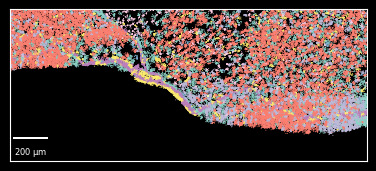

In [17]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(13.5 * CM, 5 * CM))

    sns.scatterplot(
        data=coordinate_df_3d[lambda df: df.y.between(*ylim) & df.x.between(*xlim)][
            ::10
        ],
        s=0.5,
        ax=ax,
        **ct_scatter_kwargs,
    )

    ax.set(**ax_kwargs, **ax_lims)

    ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("proseg_celltypes.svg", **save_kwargs)

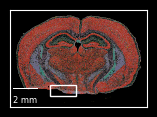

In [18]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(4.5 * CM, 5 * CM))

    sns.scatterplot(data=coordinate_df_3d[::50], s=0.01, ax=ax, **ct_scatter_kwargs)
    ax.set(**ax_kwargs)
    ax.add_artist(
        plt.Rectangle(
            (xlim[0], ylim[0]),
            xlim[1] - xlim[0],
            ylim[1] - ylim[0],
            fill=False,
            edgecolor="w",
            lw=1,
        )
    )
    ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("proseg_celltypes_global.svg", **save_kwargs)

/tmp/ipykernel_674013/698273302.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles=[plt.scatter([], [], c=c, label=l) for l, c in ct_cmap.items()],


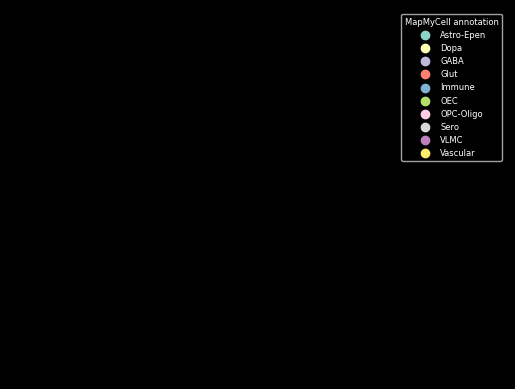

In [19]:
with plt.style.context("dark_background"):
    plt.legend(
        handles=[plt.scatter([], [], c=c, label=l) for l, c in ct_cmap.items()],
        title="MapMyCell annotation",
    )
    plt.axis("off")

    plt.savefig("proseg_celltypes_legend.svg", **save_kwargs)

#### Slice up the VLMC into a 'clean' and 'folded' part, show that we have DEGs that are e.g. Astrocyte markers;

In [23]:
# ovrlpy analysis is shifted compared to original coordinates
origin = (
    ovrlpy.io.read_Xenium(data_folder / "transcripts.parquet").select(("x", "y")).min()
)

x_origin, y_origin = origin.row(0)

xlim_shift = tuple(x - round(x_origin) for x in xlim)
ylim_shift = tuple(y - round(y_origin) for y in ylim)

In [24]:
import pickle

with open("../xenium_brain.pickle", "rb") as file:
    brain = pickle.load(file)

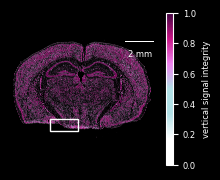

In [25]:
fig = ovrlpy.plot_signal_integrity(
    brain,
    histogram=False,
    scalebar=dict(dx=1, units="um", frameon=False, color="w"),
    figsize=(6 * CM, 5 * CM),
)

ax = fig.axes[0]
ax.set(xticks=[], yticks=[])
ax.set_axis_off()
ax.add_artist(
    plt.Rectangle(
        (xlim_shift[0], ylim_shift[0]),
        xlim_shift[1] - xlim_shift[0],
        ylim_shift[1] - ylim_shift[0],
        fill=False,
        edgecolor="w",
        lw=1,
    )
)

fig.savefig("signal_integrity.svg", **save_kwargs)

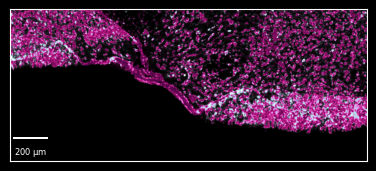

In [26]:
integrity = brain.integrity_map.copy()

xrange = slice(*xlim_shift)
yrange = slice(*ylim_shift)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(13.5 * CM, 5 * CM))

    _plot_signal_integrity(
        ax, integrity[yrange, xrange], brain.signal_map[yrange, xrange], 2
    )

    ax.set(xticks=[], yticks=[])
    ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("signal_integrity_area.svg", **save_kwargs)

In [27]:
signal_integrity = brain.integrity_map.copy()
signal_strength = brain.signal_map.copy()

In [28]:
signal_integrity[signal_strength == 0] = np.nan

cells["sampled_integrity"] = signal_integrity[
    (cells["centroid_y"] - y_origin).astype(int),
    (cells["centroid_x"] - x_origin).astype(int),
]
cells["class_correlation_coefficient"] = mapmycells_df_3d[
    "class_correlation_coefficient"
][cells.index]

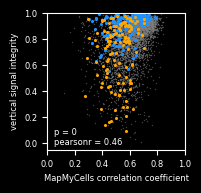

In [29]:
from scipy.stats import pearsonr

isna = cells["sampled_integrity"].isna()
pearson, p = pearsonr(
    cells["class_correlation_coefficient"][~isna],
    cells["sampled_integrity"][~isna],
)


with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(4.5 * CM, 4.5 * CM))

    scatter_kwargs = dict(
        x="class_correlation_coefficient", y="sampled_integrity", lw=0, ax=ax
    )

    plain_vlmc_mask[isna] = False
    overlap_vlmc_mask[isna] = False

    sns.scatterplot(
        data=cells[area_of_interest], s=1, c="grey", alpha=0.5, **scatter_kwargs
    )

    sns.scatterplot(data=cells[plain_vlmc_mask], s=5, c="dodgerblue", **scatter_kwargs)
    sns.scatterplot(data=cells[overlap_vlmc_mask], s=5, c="orange", **scatter_kwargs)
    ax.set(
        xlabel="MapMyCells correlation coefficient",
        ylabel="vertical signal integrity",
        xlim=(0, 1),
        ylim=(None, 1),
    )
    ax.text(
        s=f"p = {p:.2g}\npearsonr = {pearson:.2f}",
        ha="left",
        va="bottom",
        x=0.05,
        y=-0.03,
        color="w",
    )

fig.savefig("proseg_integrity_correlation.svg", **save_kwargs)

In [30]:
from scipy.stats import chi2_contingency

vlmc_mask = plain_vlmc_mask | overlap_vlmc_mask

# Create a contingency table
contingency_table = pd.crosstab(
    (cells.loc[vlmc_mask, "class_correlation_coefficient"] > 0.5),
    (cells.loc[vlmc_mask, "sampled_integrity"] > 0.7),
)

# Perform the chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared test statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-squared test statistic: 16.7385184297188
p-value: 4.2901091620928944e-05
Degrees of freedom: 1
Expected frequencies: [[ 18.36792453  80.63207547]
 [ 40.63207547 178.36792453]]


In [31]:
from scipy.stats import fisher_exact

fisher_exact(contingency_table, alternative="greater")

SignificanceResult(statistic=3.396351575456053, pvalue=3.552737489494535e-05)